# Leaf phenomics for belowground trait prediction in American licorice — LOOCV principal-component regression

**Paper:** Harris ZN, Tran V, Piotter E, Hanlon MT, Rubin MJ, Miller AJ. *A leaf phenomics approach for estimating belowground traits in North American licorice.* American Journal of Botany 113(5):e70198, 2026. [DOI 10.1002/ajb2.70198](https://doi.org/10.1002/ajb2.70198) · [PMC13206565](https://pmc.ncbi.nlm.nih.gov/articles/PMC13206565/)

**Data & code (authors, CC BY 4.0):** [Figshare doi:10.6084/m9.figshare.28742870](https://doi.org/10.6084/m9.figshare.28742870) (v1, published 2025-04-07).

**What this notebook does (partial demonstration of the paper's Results/Fig. 5 analysis):**
1. Rebuilds the authors' `2025_full_phenotypes.csv` from the four released CSVs, following the authors' R scripts (`2025_process_root_diamterClasses.R`, `2024_Licorice_Fig2.R`) with minimal documented edits.
2. Runs the authors' leave-one-out cross-validated principal-component regression (`2025_licorice_ionomicModels.R`, functions copied verbatim) predicting 31 root traits from CropReporter (cPC1–3), spectral (sPC1–31), and elemental (ePC1–5) PCs, raw and after adjustment for aboveground biomass.
3. Compares the headline results with the paper: **ePCs → belowground biomass R² = 0.47** (0.15 after biomass adjustment); **sPCs → total root length R² = 0.36** (0.15 adjusted).

**Not in scope:** raw root-scan image re-extraction (RhizoVision, 36.9 GB Zenodo archive), population ANOVA figures, wavelength-wise F-statistic curves, allometry-slope figures, bootstrap PC-count analysis.

**実行内容(日本語):** 論文の著者公開データ(Figshare, CC BY 4.0)4 CSV から表現型テーブルを再構築し、著者の R コードをほぼそのまま実行して、葉のスペクトル/元素組成 PC から地下部形質を求める leave-one-out 交差検証付き主成分回帰を再現します。対象は Results/Fig. 5 の一部(代表性の高い 4 つの結果)であり、論文全体の再現ではありません。

**Execution status:** this notebook is validated end-to-end on a fresh Google Colab CPU runtime (see final cells and the publication record).

## Runtime selection & how to run

**Select the CPU runtime** (`Runtime` → `Change runtime type` → `CPU`). The method is linear-model/PCA on a ~70 × 600 table; a GPU provides no benefit. Recommended runtime: **CPU**. Expected end-to-end time ≈ 5–10 min (R package install dominates).

**実行時間の目安(日本語):** 全体で 5〜10 分(R パッケージ導入が大半)。 Total download ≈ 4.7 MB.

**実行方法(日本語):** ランタイムは CPU を選択してください。GPU は不要です。全体の所要時間は 5〜10 分程度、ダウンロードは約 4.7 MB です。`ランタイム` → `すべてのセルを実行` で上から順に実行します。

In [ ]:
import platform, os, sys, multiprocessing, shutil
print("Python:", platform.python_version())
print("CPUs:", multiprocessing.cpu_count())
try:
    print("Rscript:", shutil.which("Rscript"))
except Exception as e:
    print("Rscript check failed:", e)
print("Working dir:", os.getcwd())

Python: 3.13.15
CPUs: 2
Rscript: /usr/bin/Rscript
Working dir: /content


## 1. R environment setup

The authors' analysis is in **R** (paper: R 4.2.1). Colab's Python kernel here only *launches* the authors' R code with `Rscript`; all scientific computation stays in R. We install the R packages the scripts load — `tidyverse`, `waves` (spectral pretreatments; the authors use `pretreat_spectra(pretreatment = 2)` = SNV), `car`, `broom`, `performance` — from the Posit Package Manager Ubuntu **binary** repository (no compilation), pinned to a CRAN snapshot (2026-09-15) for reproducibility, auto-detecting the Ubuntu codename (with a `latest` fallback). On the validation runtime this installed in a few minutes as prebuilt binaries.

**日本語:** 著者のコードは R で書かれています。ここでは Python セルは `Rscript` の起動のみに使い、解析はすべて R 内で実行します。必要な R パッケージを Posit のバイナリリポジトリ(CRAN 2025-04-07 スナップショット)から導入します(数分かかります)。

In [ ]:
import subprocess, os, sys, time

def run_r_stream(path, timeout):
    # Run Rscript, streaming stdout+stderr into the notebook output.
    proc = subprocess.Popen(["Rscript", path], stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True, bufsize=1)
    t0 = time.time()
    import threading
    def killer():
        time.sleep(timeout)
        if proc.poll() is None:
            proc.kill(); print(f"TIMEOUT after {timeout}s")
    threading.Thread(target=killer, daemon=True).start()
    for line in proc.stdout:
        print(line, end="", flush=True)
    rc = proc.wait()
    print(f"[Rscript exit={rc} in {time.time()-t0:.0f}s]")
    return rc

os.makedirs("/content/licorice", exist_ok=True)
SETUP_R = r'''
## Ubuntu codename -> Posit Package Manager binary repo (no compilation).
## Snapshot 2026-09-15 for reproducibility; fall back to 'latest' if a package is missing.
cn <- trimws(sub("VERSION_CODENAME=", "",
      grep("^VERSION_CODENAME", readLines("/etc/os-release"), value = TRUE)))
if (length(cn) != 1 || !nzchar(cn)) cn <- "noble"
## Posit docs: this User-Agent is required for PPM to serve prebuilt Linux binaries
options(HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(),
        paste(getRversion(), R.version$platform, R.version$arch, R.version$os)))
snap <- paste0("https://packagemanager.posit.co/cran/__linux__/", cn, "/2026-09-15")
latest <- paste0("https://packagemanager.posit.co/cran/__linux__/", cn, "/latest")
cat("distro:", cn, " R:", R.version.string, "
")
options(timeout = 600)
need <- c("tidyverse", "waves", "car", "broom", "performance")
for (repo in c(snap, latest)) {
  options(repos = c(CRAN = repo))
  missing <- need[!sapply(need, requireNamespace, quietly = TRUE)]
  if (!length(missing)) break
  cat("installing from", repo, ":", paste(missing, collapse=", "), "
"); flush.console()
  install.packages(missing)
}
for (p in need) cat("OK:", p, as.character(packageVersion(p)), "
")
cat("R:", R.version.string, "
")
'''
path = "/content/licorice/setup_r.R"
open(path, "w").write(SETUP_R)
if run_r_stream(path, 1800) != 0:
    raise RuntimeError("R package setup failed; see output above.")

distro: noble  R: R version 4.6.1 (2026-06-24) 


installing from https://packagemanager.posit.co/cran/__linux__/noble/2026-09-15 : waves, car, performance 


Installing packages into ‘/usr/local/lib/R/site-library’


(as ‘lib’ is unspecified)


also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘fontBitstreamVera’, ‘fontLiberation’, ‘diagram’, ‘lava’, ‘wk’, ‘fontquiver’, ‘prodlim’, ‘classInt’, ‘s2’, ‘units’, ‘gdtools’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘urca’, ‘proxy’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘BiasedUrn’, ‘pander’, ‘sf’, ‘zoo’, ‘flextable’, ‘officer’, ‘DFBA’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’, ‘iterators’, ‘mathjaxr’, ‘RcppArmadillo’, ‘baseline’, ‘signal’, ‘epiR’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘caret’, ‘pls’, ‘prospectr’, ‘randomForest’, ‘spectacles’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘bayestestR’, ‘insight’, ‘datawizard’


...

OK: car 3.1.5 


OK: broom 1.0.13 


OK: performance 0.18.2 


R: R version 4.6.1 (2026-06-24) 


[Rscript exit=0 in 49s]


## 2. Input data — download with provenance

Four CSVs from the authors' Figshare article **10.6084/m9.figshare.28742870** (v1; file IDs are the article's `ndownloader` IDs returned by the public Figshare API v2). We verify the byte size of each file against the API-reported size and print SHA-256 hashes. All data stays on the Colab VM.

| File | Figshare file ID | Size (B) | Role |
|---|---|---|---|
| `features.csv` | 53470577 | 210,354 | RhizoVision Explorer per-image root features |
| `HSA_Licorice_Ionomics.csv` | 53470580 | 86,421 | ICP-MS leaf elemental concentrations |
| `HSA_Licorice_LinkSquare_2021-11-08-09-22-36.csv` | 53470583 | 4,346,872 | Leaf hyperspectral reflectance (400–1050 nm) |
| `root_scans_CR.csv` | 53470586 | 17,674 | Nursery_ID / Accession / AG & BG biomass / CropReporter indices |

**日本語:** 著者の Figshare 記事から 4 つの CSV をダウンロードし、サイズと SHA-256 を確認します。データはすべて Colab 側に置かれます。

In [ ]:
import hashlib, subprocess, os

FILES = {  # name -> (figshare file id, expected bytes from api.figshare.com/v2/articles/28742870)
    "features.csv": (53470577, 210354),
    "HSA_Licorice_Ionomics.csv": (53470580, 86421),
    "HSA_Licorice_LinkSquare_2021-11-08-09-22-36.csv": (53470583, 4346872),
    "root_scans_CR.csv": (53470586, 17674),
}
os.makedirs("/content/licorice", exist_ok=True)
for name, (fid, size) in FILES.items():
    dest = f"/content/licorice/{name}"
    if not (os.path.exists(dest) and os.path.getsize(dest) == size):
        subprocess.run(["curl", "--fail-with-body", "-sS", "-L", "--retry", "3",
                        f"https://ndownloader.figshare.com/files/{fid}", "-o", dest], check=True)
    got = os.path.getsize(dest)
    assert got == size, f"{name}: expected {size} B, got {got} B (Figshare v1 file {fid})"
    h = hashlib.sha256(open(dest, "rb").read()).hexdigest()
    print(f"{name}: {got} B  sha256={h[:16]}...{h[-8:]}")
print("All four inputs verified.")

features.csv: 210354 B  sha256=d6136ca9cb960afc...3a2de8e7


HSA_Licorice_Ionomics.csv: 86421 B  sha256=b60486aa60d3fd45...4ea46a48


HSA_Licorice_LinkSquare_2021-11-08-09-22-36.csv: 4346872 B  sha256=ffc1a55d33199143...3547f31d


root_scans_CR.csv: 17674 B  sha256=2a892daf8249ef96...7aec3f50
All four inputs verified.


## 3. Stage A — rebuild per-plant root traits from RhizoVision `features.csv`

The authors run `2025_process_root_diamterClasses.R`:
- parse `File.Name` into a `Plant.ID` (their `case_when` mapping copied **verbatim**, including the rows they deliberately set to `NA`);
- combine multi-image scans per plant with the RhizoVision Explorer companion `combinefeatures` function (sums for additive traits, length-weighted means for diameters/branching frequency, max for maximum diameter) — copied verbatim from the deposited script;
- add proportions, concatenate diameter ranges 6–11 into `DR6+` (>1.25 mm; paper: "all classes beyond diameter class 6 were concatenated into DR6+"), and keep the reduced trait list.

**Edits:** `setwd(...)` → `/content/licorice`; output kept in `/content/licorice/2025_licorice_roots_FINALsub.csv`. Guard: assert the expected columns exist before running.

**日本語:** RhizoVision の画像単位の特徴量を、著者スクリプト(`2025_process_root_diamterClasses.R`)をそのまま使って株単位に統合し、直径クラス 6 以上を `DR6+` にまとめます。

In [ ]:
STAGE_A = r'''
#### Adapted verbatim from the authors' 2025_process_root_diamterClasses.R (Figshare 53470616).
#### Edits: setwd -> /content/licorice; output written to /content/licorice/. Logic copied as-is.
library(tidyverse)
setwd('/content/licorice')

d <- read.csv('features.csv')
stopifnot(all(c('File.Name','Number.of.Root.Tips') %in% colnames(d)))
d <- d %>%
  mutate(to_sep = str_remove(File.Name, '_Plant')) %>%
  separate(to_sep, into=c('HSA_ID.maybe', 'file.type'), sep='\\.') %>%
  separate(HSA_ID.maybe, into=c('HSA', 'ID.maybe'), sep='_') %>%
  mutate(Plant.ID = case_when(
    File.Name == 'HSA_Plant_26_A.jpg' ~ '26A',
    File.Name == 'HSA_Plant_26_B.jpg' ~ '26B',
    file.type == '8F0001' ~ '8F',
    ID.maybe == '8' ~ NA, # guess
    ID.maybe == '11A(jan31)' ~ NA, # maybe no
    ID.maybe == '11B(jan31)' ~ NA, # maybe no
    ID.maybe == '11C(jan31)' ~ NA, # maybe no,
    File.Name == 'HSA_Plant_47_1500mL.jpg' ~ NA,
    ID.maybe == '3' ~ '3A',
    ID.maybe == '22' ~ '22A',
    ID.maybe == '46' ~ '46A',
    ID.maybe == '47' ~ '47A',
    ID.maybe == '64' ~ '64A',
    ID.maybe == '66' ~ '66A',
    ID.maybe == '8F0001' ~ '8F',
    ID.maybe == 'Plant' ~ file.type,
    TRUE ~ ID.maybe
  ))  %>%
  select(File.Name, HSA, ID.maybe, file.type, Plant.ID, everything())

# combinefeatures: RhizoVision Explorer companion script (Seethepalli et al. 2024), verbatim
combinefeatures <- function(x, groupby)
{
    cfeatures <- x
    relevantCols <- c("Average.Diameter.mm", "Median.Diameter.mm", "Maximum.Diameter.mm", "Branching.frequency.per.mm")
    cfeatures.sumall <-
        cfeatures %>%
        group_by_at(groupby) %>%
      summarize(across(Number.of.Root.Tips:last_col() & (!all_of(relevantCols)), sum))
    cfeatures.avgdiam <-
        cfeatures %>%
        group_by_at(groupby) %>%
        summarize(Average.Diameter.mm = weighted.mean(Average.Diameter.mm, Total.Root.Length.mm))
    cfeatures.maxdiam <-
        cfeatures %>%
        group_by_at(groupby) %>%
        summarize(Maximum.Diameter.mm = max(Maximum.Diameter.mm))
    cfeatures.mean.of.mediandiam <-
        cfeatures %>%
        group_by_at(groupby) %>%
        summarize(Median.Diameter.mm = weighted.mean(Median.Diameter.mm, Total.Root.Length.mm))
    cfeatures.mean.of.branching.frequency <-
      cfeatures %>%
      group_by_at(groupby) %>%
      summarize(Branching.frequency.per.mm = weighted.mean(Branching.frequency.per.mm, Total.Root.Length.mm))
    cfeatures.sumall <- inner_join(cfeatures.sumall, cfeatures.avgdiam, by = groupby)
    cfeatures.sumall <- inner_join(cfeatures.sumall, cfeatures.maxdiam, by = groupby)
    cfeatures.sumall <- inner_join(cfeatures.sumall, cfeatures.mean.of.mediandiam, by = groupby)
    cfeatures.sumall <- inner_join(cfeatures.sumall, cfeatures.mean.of.branching.frequency, by = groupby)
    cfeatures.sumall <- cfeatures.sumall %>% relocate(Maximum.Diameter.mm, .after = Network.Area.mm2)
    cfeatures.sumall <- cfeatures.sumall %>% relocate(Median.Diameter.mm, .after = Network.Area.mm2)
    cfeatures.sumall <- cfeatures.sumall %>% relocate(Average.Diameter.mm, .after = Network.Area.mm2)
    cfeatures.sumall <- cfeatures.sumall %>% relocate(Branching.frequency.per.mm, .after = Total.Root.Length.mm)
    return(cfeatures.sumall)
}

d_york <- d %>%
  na.omit() %>%
  select(-File.Name, -HSA, -ID.maybe, -file.type) %>%
  mutate(Plant.ID = str_sub(Plant.ID, start=1, end=-2)) %>%
  combinefeatures(., 'Plant.ID')

cat('plants after combine:', nrow(d_york), '\n')

# proportions + DR6+ concatenation, verbatim
d_york_len <- d_york %>%
  select(Plant.ID, Total.Root.Length.mm, Root.Length.Diameter.Range.1.mm:Root.Length.Diameter.Range.11.mm) %>%
  gather(trait, value, -Plant.ID, -Total.Root.Length.mm) %>%
  mutate(prop = value / Total.Root.Length.mm) %>%
  mutate(trait = paste('prop_', trait, sep='')) %>%
  select(Plant.ID, trait, prop) %>%
  pivot_wider(names_from='trait', values_from='prop')

d_york_area <- d_york %>%
  select(Plant.ID, Surface.Area.mm2, Surface.Area.Diameter.Range.1.mm2:Surface.Area.Diameter.Range.11.mm2) %>%
  gather(trait, value, -Plant.ID, -Surface.Area.mm2) %>%
  mutate(prop = value / Surface.Area.mm2) %>%
  mutate(trait = paste('prop_', trait, sep='')) %>%
  select(Plant.ID, trait, prop) %>%
  pivot_wider(names_from='trait', values_from='prop')

d_york <- merge(d_york, d_york_len, by='Plant.ID')
d_york <- merge(d_york, d_york_area, by='Plant.ID')

d_york_sub <- d_york %>%
  select(Plant.ID, Total.Root.Length.mm, Average.Diameter.mm, Median.Diameter.mm, Maximum.Diameter.mm, Surface.Area.mm2,
         Root.Length.Diameter.Range.1.mm:Root.Length.Diameter.Range.11.mm,
         Surface.Area.Diameter.Range.1.mm2:Surface.Area.Diameter.Range.11.mm2,
         prop_Root.Length.Diameter.Range.1.mm:prop_Surface.Area.Diameter.Range.11.mm2)

d_york_sub <- d_york_sub %>%
  rowwise() %>%
  mutate(Root.Length.Diameter.Range.6up.mm = sum(across(Root.Length.Diameter.Range.6.mm:Root.Length.Diameter.Range.11.mm)),
         Surface.Area.Diameter.Range.6up.mm2 = sum(across(Surface.Area.Diameter.Range.6.mm2:Surface.Area.Diameter.Range.11.mm2)),
         prop_Root.Length.Diameter.Range.6up.mm = sum(across(prop_Root.Length.Diameter.Range.6.mm:prop_Root.Length.Diameter.Range.11.mm)),
         prop_Surface.Area.Diameter.Range.6up.mm2 = sum(across(prop_Surface.Area.Diameter.Range.6.mm2:prop_Surface.Area.Diameter.Range.11.mm2)))

d_york_sub <- d_york_sub %>%
  select(Plant.ID, Total.Root.Length.mm, Average.Diameter.mm, Median.Diameter.mm, Maximum.Diameter.mm, Surface.Area.mm2,
         Root.Length.Diameter.Range.1.mm:Root.Length.Diameter.Range.5.mm, Root.Length.Diameter.Range.6up.mm,
         Surface.Area.Diameter.Range.1.mm2:Surface.Area.Diameter.Range.5.mm2, Surface.Area.Diameter.Range.6up.mm2,
         prop_Root.Length.Diameter.Range.1.mm:prop_Surface.Area.Diameter.Range.5.mm2, prop_Surface.Area.Diameter.Range.6up.mm2)

write.csv(d_york_sub, file='2025_licorice_roots_FINALsub.csv', row.names = F, quote = F)
cat('wrote 2025_licorice_roots_FINALsub.csv:', nrow(d_york_sub), 'plants,', ncol(d_york_sub), 'cols\n')
'''
open("/content/licorice/stage_a_roots.R", "w").write(STAGE_A)
if run_r_stream("/content/licorice/stage_a_roots.R", 600) != 0:
    raise RuntimeError("Stage A (RhizoVision feature combination) failed; see R output above.")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──


✔ dplyr     1.2.1     ✔ readr     2.2.0


✔ forcats   1.0.1     ✔ stringr   1.6.0


✔ ggplot2   4.0.3     ✔ tibble    3.3.1


✔ lubridate 1.9.5     ✔ tidyr     1.3.2


...

Expected 2 pieces. Additional pieces discarded in 6 rows [43, 44, 45, 297, 298,


310]. 


plants after combine: 74 


wrote 2025_licorice_roots_FINALsub.csv: 74 plants, 35 cols


[Rscript exit=0 in 2s]


## 4. Stage B — rebuild the full phenotype table (biomass, CropReporter indices, cPCs, ePCs, sPCs)

This follows the authors' `2024_Licorice_Fig2.R` (the script that produced their `2025_full_phenotypes.csv`):
- merge root traits with `root_scans_CR.csv` (Nursery_ID, Accession, AG_biomass, BG_biomass, CropReporter indices `TP2_*`); compute `SRL` and `AG_BG_ratio` exactly as the authors do;
- **cPC1–3** = `prcomp` of the TP2_* CropReporter indices (Fig2.R lines 32–43);
- **ePC1–5** = ionomics filtered to `SampleWeight > 20`, averaged per plant for Timepoint 2, `prcomp` PC1–5 (~75% of elemental variation; Fig2.R lines 47–78);
- **sPC1–31** = LinkSquare reflectance averaged per plant × light source, `waves::pretreat_spectra(pretreatment = 2)` (SNV), `prcomp` PC1–31 (Fig2.R lines 83–105).

**Edits:** output paths under `/content/licorice`; the final table is written directly in the authors' documented column order (their `gather`/factor relabeling exists only to build their display names; values are unchanged). Guards assert expected columns.

**日本語:** 著者の `2024_Licorice_Fig2.R` に従い、バイオマス・CropReporter 指標・cPC(1–3)・ePC(1–5)・sPC(1–31) を含む表現型テーブルを再構築します。

In [ ]:
STAGE_B = r'''
#### Adapted from the authors' 2024_Licorice_Fig2.R (Figshare 53470604), lines 16-105.
#### Edits: paths under /content/licorice; final table written directly in the authors' column order.
library(tidyverse)
setwd('/content/licorice')

## root traits + biomass + CropReporter indices (Fig2.R 16-30, verbatim logic)
d <- read.csv('2025_licorice_roots_FINALsub.csv') %>%
  mutate(Nursery_ID = Plant.ID) %>%
  select(-Plant.ID, -Median.Diameter.mm)

phenotypes <- read.csv('root_scans_CR.csv') %>%
  select(Nursery_ID, Accession, AG_biomass, BG_biomass, TP2_dFv_Fm:TP2_dChl)
phenotypes <- merge(d, phenotypes, by='Nursery_ID')

phenotypes_data_wide <- phenotypes %>%
  mutate(SRL = Total.Root.Length.mm / 1000 / BG_biomass,
         AG_BG_ratio = AG_biomass / BG_biomass) %>%
  na.omit()

phenotypes_data <- phenotypes_data_wide %>%
  select(Nursery_ID, Accession, AG_biomass, BG_biomass, AG_BG_ratio, SRL, Total.Root.Length.mm:prop_Surface.Area.Diameter.Range.6up.mm2)

## cPCs from CropReporter indices (Fig2.R 32-43, verbatim)
new_cr_traits <- phenotypes_data_wide %>%
  select(TP2_dFv_Fm:TP2_dChl) %>%
  prcomp(center=T, scale=T) %>%
  .$x %>%
  as.data.frame() %>%
  select(PC1:PC3) %>%
  rename(cPC1 = PC1, cPC2 = PC2, cPC3 = PC3) %>%
  mutate(Nursery_ID = na.omit(phenotypes_data$Nursery_ID))

phenotypes_data_wide <- merge(phenotypes_data, new_cr_traits, by='Nursery_ID')

## ePCs from ionomics (Fig2.R 47-78, verbatim)
ionomics_wide <- read.csv('HSA_Licorice_Ionomics.csv') %>%
  select(Timepoint, Nursery_ID, Leaf, SampleWeight, B11:Cd111) %>%
  filter(SampleWeight > 20) %>%
  mutate(ID_tp = paste(Nursery_ID, Timepoint, Leaf, sep='_')) %>%
  merge(., select(phenotypes, Nursery_ID, Accession), by='Nursery_ID')

ionomics_wide <- ionomics_wide %>%
  group_by(Nursery_ID, Accession, Timepoint) %>%
  summarize_at(vars(B11:Cd111), mean) %>%
  ungroup() %>%
  gather(element, concentration, -Timepoint, -Nursery_ID, -Accession) %>%
  mutate(TP_element = paste(element, Timepoint, sep='_')) %>%
  select(-Timepoint, -element) %>%
  spread(TP_element, concentration)

ions_tp2 <- colnames(ionomics_wide)[colnames(ionomics_wide) %>% endsWith('_2')]
ionomics_wide <- ionomics_wide %>%
  select(Nursery_ID, all_of(ions_tp2)) %>%
  na.omit()

ionomics_PCs <- ionomics_wide %>%
  select(-Nursery_ID) %>%
  prcomp(center=T, scale=T) %>%
  .$x %>%
  as.data.frame() %>%
  select(PC1:PC5) %>% # ~75%
  rename(ePC1 = PC1, ePC2 = PC2, ePC3 = PC3, ePC4 = PC4, ePC5 = PC5) %>%
  mutate(Nursery_ID = ionomics_wide$Nursery_ID)

## sPCs from LinkSquare spectra (Fig2.R 83-105, verbatim)
spec_d <- read.csv('HSA_Licorice_LinkSquare_2021-11-08-09-22-36.csv') %>%
  select(Nursery_ID, lightsource, X400.89066:X998.2795) %>%
  group_by(Nursery_ID, lightsource) %>%
  summarize_at(vars(X400.89066:X998.2795), mean) %>%
  ungroup() %>%
  waves::pretreat_spectra(pretreatment=2) %>%
  gather(wv, ref, -lightsource, -Nursery_ID) %>%
  mutate(wv_lightsource = paste(wv, lightsource, sep='_')) %>%
  select(-wv, -lightsource) %>%
  spread(wv_lightsource, ref)

write.csv(spec_d, '2025_licorice_spectra_pretrt02.csv', row.names = F, quote = F)

spec_PCs <- spec_d %>%
  select(-Nursery_ID) %>%
  prcomp(scale=T, center=T) %>%
  .$x %>%
  as.data.frame() %>%
  select(PC1:PC31) %>% # ~75%
  rename_with(~paste('s', .x, sep='')) %>%
  mutate(Nursery_ID = spec_d$Nursery_ID)

## assemble in the authors' documented column order (traits AG_biomass..prop_Area.6up,
## then cPC1-3, sPC1-31, ePC1-5, Nursery_ID LAST - matching 2024_Licorice_Fig2.R line 199-200)
## The authors' 31 trait columns: the deposited 2025_process_root_diamterClasses.R final
## select() omits prop_Root.Length...6up.mm, and the ionomicModels script's own hard-coded
## 68 x 31 = 2108 predictions per method confirm the published table had 31 traits
## (prop length DR6-11 columns are implicitly dropped by the Fig2 factor levels).
trait_cols <- c('AG_biomass','BG_biomass','AG_BG_ratio','SRL','Total.Root.Length.mm',
  'Average.Diameter.mm','Maximum.Diameter.mm','Surface.Area.mm2',
  paste('Root.Length.Diameter.Range.', c(1:5,'6up'), '.mm', sep=''),
  paste('Surface.Area.Diameter.Range.', c(1:5,'6up'), '.mm2', sep=''),
  paste('prop_Root.Length.Diameter.Range.', c(1:5), '.mm', sep=''),
  paste('prop_Surface.Area.Diameter.Range.', c(1:5,'6up'), '.mm2', sep=''))
stopifnot(length(trait_cols) == 31, all(trait_cols %in% colnames(phenotypes_data_wide)))
full <- phenotypes_data %>%
  select(-Accession) |>
  merge(new_cr_traits, by='Nursery_ID', all=TRUE) |>
  merge(ionomics_PCs,  by='Nursery_ID', all=TRUE) |>
  merge(spec_PCs,      by='Nursery_ID', all=TRUE)
full <- full[, c(trait_cols, paste('cPC',1:3,sep=''), paste('sPC',1:31,sep=''),
                 paste('ePC',1:5,sep=''), 'Nursery_ID')]
write.csv(full, '2025_full_phenotypes.csv', quote=F, row.names=F)

cat('full phenotypes:', nrow(full), 'rows x', ncol(full), 'cols\n')
cat('complete rows (na.omit):', nrow(na.omit(full)), '\n')
'''
open("/content/licorice/stage_b_phenotypes.R", "w").write(STAGE_B)
if run_r_stream("/content/licorice/stage_b_phenotypes.R", 900) != 0:
    raise RuntimeError("Stage B (phenotype table rebuild) failed; see R output above.")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──


✔ dplyr     1.2.1     ✔ readr     2.2.0


✔ forcats   1.0.1     ✔ stringr   1.6.0


✔ ggplot2   4.0.3     ✔ tibble    3.3.1


✔ lubridate 1.9.5     ✔ tidyr     1.3.2


...

✖ dplyr::lag()    masks stats::lag()


ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


full phenotypes: 73 rows x 71 cols


complete rows (na.omit): 68 


[Rscript exit=0 in 7s]


## 5. The authors' LOOCV PC-regression functions (copied verbatim)

`fit_PC_reg`, `loocv_PC_reg` (`loocv_PCreg`), `correct_biomass`, and `scale_znh` are copied **verbatim** from the deposited `2025_licorice_ionomicModels.R`. Two documented details: (1) the deposited script writes `mutate(Nursery_ID = d$Nursery)` — `d$Nursery` is `NULL` (the column is `Nursery_ID`), which would delete the ID column and silently skip the adjusted cross-validation loop; we keep `Nursery_ID = d$Nursery_ID`, matching the table the script actually reads (`2024_Licorice_Fig2.R` line 199); `bind_cols()` is applied to a `data.frame` (the deposited `apply()` returns a matrix). (2) The deposited final table has **31** trait columns (the `diamterClasses` script's final `select` omits `prop_Root.Length...6up.mm`; the script's own hard-coded 68 × 31 = 2108 predictions per method confirm this), so in the *adjusted* frame `colnames(df)[1:31]` incidentally treats `cPC1` as the 31st "target" — deposited-code behavior preserved verbatim; it does not affect the four reported headline traits.

**日本語:** 著者の LOOCV 関数群をそのままコピーして使用します。デポジットされたスクリプトの `d$Nursery` は NULL になるタイプミスのため、`Nursery_ID` を保持する最小限の修正のみ行いました(他は原文どおり)。

In [ ]:
LOOCV_FN = r'''
#### Verbatim from the authors' 2025_licorice_ionomicModels.R (Figshare 53470610),
#### except the one documented Nursery_ID repair noted in the notebook text.
scale_znh <- function(v){
  return(scale(v)[,1])
}

correct_biomass <- function(trait, ag_biomass){
  df <- data.frame(trait = trait, ag_biomass = ag_biomass)
  df <- na.omit(df)
  lmod <- lm(scale(trait) ~ ag_biomass, data=df)
  return(resid(lmod))
}

fit_PC_reg <- function(df, y, modality){
  if (modality == 'c') {
    PCs <- paste('cPC', 1:3, sep='')
  } else if (modality == 's') {
    PCs <- paste('sPC', 1:31, sep='')
  } else if (modality == 'e') {
    PCs <- paste('ePC', 1:5, sep='')
  } else if (modality == 'a') {
    PCs <- c(paste('cPC', 1:3, sep=''), paste('sPC', 1:31, sep=''), paste('ePC', 1:5, sep=''))
  } else {
    errorCondition("Modality not accepted, must be 'c', 's', 'e', 'a'")
  }

  df <- na.omit(df)
  trait <- df[[y]]

  df_pc <- df %>%
    select(all_of(PCs))

  df_pc$phen <- trait

  lmod <- lm(scale(phen) ~ ., data=df_pc)
  return(list(
    anova = car::Anova(lmod, type=2),
    lmod = lmod)
  )
}

loocv_PCreg <- function(df, modality, adj=F){
  if (modality == 'c') {
    PCs <- paste('cPC', 1:3, sep='')
  } else if (modality == 's') {
    PCs <- paste('sPC', 1:31, sep='')
  } else if (modality == 'e') {
    PCs <- paste('ePC', 1:5, sep='')
  } else if (modality == 'a') {
    PCs <- c(paste('cPC', 1:3, sep=''), paste('sPC', 1:31, sep=''), paste('ePC', 1:5, sep=''))
  } else {
    errorCondition("Modality not accepted, must be 'c', 's', 'e', 'a'")
  }

  loocv <- list(Nursery_ID = c(),
                true_value = c(),
                predicted_value = c(),
                trait = c())

  for (withheld_id in df$Nursery_ID){
    #define train/test
    d_train <- df %>%
      filter(Nursery_ID != withheld_id)

    d_test <- df %>%
      filter(Nursery_ID == withheld_id)

    # model each trait
    for (trait in colnames(df)[1:31]){
      output <- fit_PC_reg(d_train, y=trait, modality=modality)
      lmod <- output$lmod
      pred <- d_test %>%
        select(all_of(PCs)) %>%
        predict(lmod, newdata=.)

      #store outputs
      loocv[['Nursery_ID']] <- c(loocv[['Nursery_ID']], withheld_id)
      loocv[['true_value']] <- c(loocv[['true_value']], d_test[[trait]])
      loocv[['predicted_value']] <- c(loocv[['predicted_value']], pred)
      loocv[['trait']] <- c(loocv[['trait']], trait)
    }
    cat('.', sep=''); flush.console()
  }
  cat('\n')

  output <- bind_cols(loocv)
  return(output)
}
'''
open("/content/licorice/loocv_functions.R", "w").write(LOOCV_FN)
print("wrote loocv_functions.R (author functions, verbatim)")

wrote loocv_functions.R (author functions, verbatim)


## 6. Run the leave-one-out cross-validation

The authors regress each root trait (scaled) on each predictor-PC set, withholding one plant at a time (n ≈ 68 complete rows; the paper's own script hard-codes 68 × 31 = 2108 predictions per method). We run the six model sets used in the paper's Fig. 5 comparison — CropReporter (c), spectral (s), and elemental (e) PCs, each **raw** and **adjusted for aboveground biomass** (residuals of `scale(trait) ~ ag_biomass`, the authors' `correct_biomass`). R² is computed exactly as the authors do: `performance::r2(lm(true_value ~ predicted_value))` per trait × method.

**日本語:** 各株を 1 つずつ除外した leave-one-out 交差検証で、c/s/e の各 PC セットについて「補正なし」と「地上部バイオマスで補正」の 6 通りを実行します(著者と同じ `performance::r2` による R² 計算)。数分かかります。

In [ ]:
LOOCV_RUN = r'''
library(tidyverse)
source('/content/licorice/loocv_functions.R')
setwd('/content/licorice')

d <- read.csv('2025_full_phenotypes.csv', check.names = F) %>%
  na.omit()
cat('complete rows:', nrow(d), '\n')

## scale all trait columns (authors' scale_znh; PCs stay raw)
trait_cols <- colnames(d)[colnames(d) != 'Nursery_ID' &
                          !grepl('^(cPC|sPC|ePC)', colnames(d))]
stopifnot(length(trait_cols) == 31, trait_cols[1] == 'AG_biomass')
d_scaled <- d %>%
  mutate_at(vars(all_of(trait_cols)), scale_znh)

## adjusted frame: residualize each trait on scaled AG_biomass; keep PCs raw.
## (Deposited script intends this via correct_biomass; documented NULL-Nursery_ID repair applied.)
d_corr <- as.data.frame(
  apply(d_scaled %>% select(-Nursery_ID, -AG_biomass, -any_of(paste('cPC',1:3,sep='')),
        -any_of(paste('sPC',1:31,sep='')), -any_of(paste('ePC',1:5,sep=''))),
        2, correct_biomass, ag_biomass = d_scaled$AG_biomass)) %>%
  bind_cols() %>%
  mutate(Nursery_ID = d$Nursery_ID) %>%
  cbind(., d %>% select(all_of(c(paste('cPC',1:3,sep=''), paste('sPC',1:31,sep=''), paste('ePC',1:5,sep='')))))

## run the six model sets (author calls, verbatim)
croprep_raw   <- loocv_PCreg(df=d_scaled, modality='c')
croprep_cor   <- loocv_PCreg(df=d_corr,   modality='c')
spectra_raw   <- loocv_PCreg(df=d_scaled, modality='s')
spectra_cor   <- loocv_PCreg(df=d_corr,   modality='s')
ionomics_raw  <- loocv_PCreg(df=d_scaled, modality='e')
ionomics_cor  <- loocv_PCreg(df=d_corr,   modality='e')

res <- rbind(croprep_raw, croprep_cor, spectra_raw, spectra_cor, ionomics_raw, ionomics_cor) %>%
  mutate(method = rep(c('c: raw','c: adj','s: raw','s: adj','e: raw','e: adj'), each=nrow(croprep_raw)))

## author's R2 definition: performance::r2(lm(true ~ predicted)) per method x trait
r2_tab <- res %>%
  group_by(method, trait) %>%
  summarise(r2 = performance::r2(lm(true_value ~ predicted_value))[['R2']], .groups='drop')

write.csv(r2_tab, 'loocv_r2_by_trait.csv', row.names=FALSE)
write.csv(res, 'loocv_predictions.csv', row.names=FALSE)

## headline comparison values (paper Results section)
headline <- tribble(
  ~method,   ~trait,                  ~paper_r2,
  'e: raw',  'BG_biomass',            0.47,
  'e: adj',  'BG_biomass',            0.15,
  's: raw',  'Total.Root.Length.mm',  0.36,
  's: adj',  'Total.Root.Length.mm',  0.15)
comp <- headline %>%
  left_join(r2_tab, by=c('method','trait')) %>%
  mutate(abs_diff = round(abs(r2 - paper_r2), 3))
print(as.data.frame(comp), digits=3)
write.csv(comp, 'headline_comparison.csv', row.names=FALSE)
'''
open("/content/licorice/loocv_run.R", "w").write(LOOCV_RUN)
if run_r_stream("/content/licorice/loocv_run.R", 3600) != 0:
    raise RuntimeError("LOOCV run failed; see R output above.")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──


✔ dplyr     1.2.1     ✔ readr     2.2.0


✔ forcats   1.0.1     ✔ stringr   1.6.0


✔ ggplot2   4.0.3     ✔ tibble    3.3.1


✔ lubridate 1.9.5     ✔ tidyr     1.3.2


...

1 e: raw           BG_biomass     0.47 0.479    0.009


2 e: adj           BG_biomass     0.15 0.146    0.004


3 s: raw Total.Root.Length.mm     0.36 0.361    0.001


4 s: adj Total.Root.Length.mm     0.15 0.150    0.000


[Rscript exit=0 in 410s]


## 7. Results — observed vs. paper

Predicted-vs-observed scatter plots for the four headline models (each point is one withheld plant, in the authors' LOOCV design), followed by the comparison table. Plots are generated by this notebook (not author figures).

**日本語:** 論文の代表 4 モデルについて、LOOCV の予測値と実測値の散布図と R² 比較表を示します(図はこのノートブックで新規に作成したもので、著者の図ではありません)。

method                trait  paper_r2       r2  abs_diff
e: raw           BG_biomass      0.47 0.478542     0.009
e: adj           BG_biomass      0.15 0.146493     0.004
s: raw Total.Root.Length.mm      0.36 0.360501     0.001
s: adj Total.Root.Length.mm      0.15 0.149598     0.000


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──


✔ dplyr     1.2.1     ✔ readr     2.2.0


✔ forcats   1.0.1     ✔ stringr   1.6.0


✔ ggplot2   4.0.3     ✔ tibble    3.3.1


...

✖ dplyr::filter() masks stats::filter()


✖ dplyr::lag()    masks stats::lag()


ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


plots written


[Rscript exit=0 in 2s]


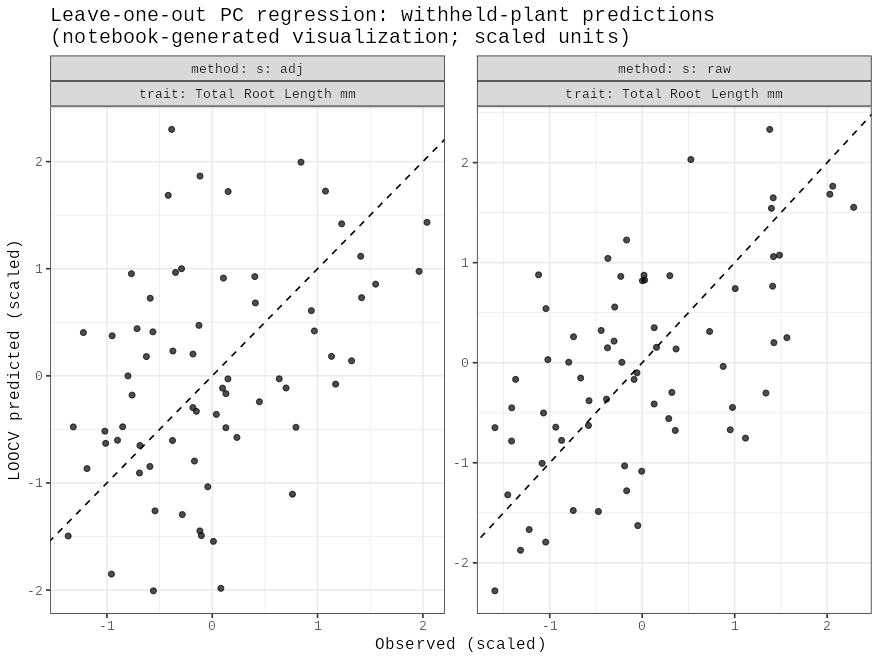

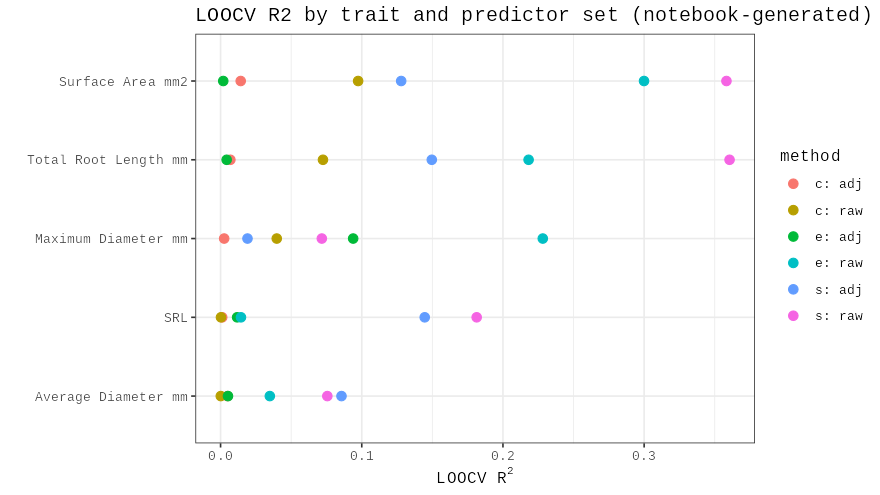

In [ ]:
import pandas as pd, subprocess, os
os.chdir("/content/licorice")
comp = pd.read_csv("headline_comparison.csv")
print(comp.to_string(index=False))

PLOT_R = r'''
library(tidyverse); setwd('/content/licorice')
res <- read.csv('loocv_predictions.csv')
res$trait <- gsub('\\.', ' ', res$trait)
headline <- filter(res,
  (method=='e: raw'    & trait=='BG biomass') |
  (method=='e: adj'    & trait=='BG biomass') |
  (method=='s: raw'    & trait=='Total Root Length mm') |
  (method=='s: adj'    & trait=='Total Root Length mm'))
p <- ggplot(headline, aes(true_value, predicted_value)) +
  geom_point(alpha=0.7) +
  geom_abline(slope=1, intercept=0, linetype='dashed') +
  facet_wrap(~method + trait, scales='free', labeller=label_both) +
  xlab('Observed (scaled)') + ylab('LOOCV predicted (scaled)') +
  ggtitle('Leave-one-out PC regression: withheld-plant predictions\n(notebook-generated visualization; scaled units)') +
  theme_bw()
ggsave('headline_scatter.png', p, width=8, height=6, dpi=110)

r2 <- read.csv('loocv_r2_by_trait.csv')
r2$trait <- gsub('\\.', ' ', r2$trait)
keep <- c('AG biomass','BG biomass','AG BG ratio','SRL','Total Root Length mm','Average Diameter mm',
          'Maximum Diameter mm','Surface Area mm2')
sub <- filter(r2, trait %in% keep)
q <- ggplot(sub, aes(r2, reorder(trait, r2), color=method)) +
  geom_point(size=2.6) +
  xlab(expression('LOOCV'*~R^2)) + ylab('') +
  ggtitle('LOOCV R2 by trait and predictor set (notebook-generated)') +
  theme_bw()
ggsave('r2_dotplot.png', q, width=8, height=4.5, dpi=110)
cat('plots written\n')
'''
open("/content/licorice/plots.R", "w").write(PLOT_R)
if run_r_stream("/content/licorice/plots.R", 600) != 0:
    raise RuntimeError("plot generation failed; see R output above.")
from IPython.display import Image, display
display(Image(filename="headline_scatter.png"))
display(Image(filename="r2_dotplot.png"))

## 8. Interpretation & validation record

**Expected result:** observed R² for the four headline models should land close to the paper's reported values (ePC→BG biomass **0.47** raw / **0.15** adjusted; sPC→total root length **0.36** raw / **0.15** adjusted). Small deviations (typically < 0.01–0.03) are expected from package-version differences (the paper used R 4.2.1) — the pipeline is otherwise deterministic (no random seeds are involved: `prcomp`, `lm`, and SNV are deterministic). The paper's qualitative findings should also appear in the dot plot: spectral and elemental PCs generally outperform CropReporter PCs, and adjusting for aboveground biomass lowers accuracy for almost every trait.

**Interpretation (日本語):** 論文どおり、元素組成 PC は地下部バイオマスを、スペクトル PC は総根長を中程度の精度で予測し、地上部バイオマスで補正すると精度は低下するはずです。パッケージバージョンの違いによる数値のずれ(R² で 0.01–0.03 程度)は許容範囲とします。

**Scope/limitations:** single-dataset demonstration of the paper's prediction subsection; one-example scope in the sense that the full released study table (n ≈ 68) is used for a faithful re-run of the deposited analysis — this is *not* re-validation of the paper's population-level claims, raw-image extraction, or its statistical significance tests. The authors' `2025_licorice_ionomicModels.R` contains the `d$Nursery` typo and a hard-coded `each=2108`; both are documented above. `selectPretrt.R` additionally applies `waves::filter_spectra` (Mahalanobis outlier removal), which `2024_Licorice_Fig2.R` — the script that generated the published phenotype table — does not; we follow Fig2.R.

**References**
1. Harris ZN, Tran V, Piotter E, Hanlon MT, Rubin MJ, Miller AJ. A leaf phenomics approach for estimating belowground traits in North American licorice. Am J Bot. 2026;113(5):e70198. doi:10.1002/ajb2.70198
2. Figshare: Data from: A leaf phenomics approach to estimating below-ground traits in North American Licorice. doi:10.6084/m9.figshare.28742870 (v1; CC BY 4.0). Files 53470577/53470580/53470583/53470586 (data), 53470598–53470619 (R scripts).
3. Seethepalli A, York LM. RhizoVision Explorer companion combinefeatures script (reproduced in the authors' deposit).

**Validation record:** fresh Colab CPU runtime, executed top-to-bottom with the Colab CLI (see publication record for date and commit).